## Setup and Imports

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../src'))

from embeddings.embedder import get_model, generate_embeddings, build_document_text, cosine_similarity, dot_product, euclidean_distance
from embeddings.chroma_store import get_collection, add_records, query_collection, get_collection_count
from embeddings.search_engine import semantic_search, keyword_search, compare_search
from embeddings.hybrid_search import hybrid_search

print('All imports successful')

All imports successful


## Understanding Embeddings


In [3]:
sample_texts = [
    'Audi A4 brake failure recall safety issue',
    'Volkswagen Golf engine stalling defect',
    'Skoda Octavia airbag malfunction warning',
    'Audi Q5 steering system recall',
    'Cupra Formentor electrical fault'
]

embeddings = generate_embeddings(sample_texts)
print(f'Embeddings shape: {embeddings.shape}')
print(f'Each embedding has {embeddings.shape[1]} dimensions')
print(f'First 5 values of embedding 0: {embeddings[0][:5]}')

2026-05-15 17:52:35,107 - INFO - Loading sentence-transformer model: all-MiniLM-L6-v2
2026-05-15 17:52:35,155 - INFO - Use pytorch device_name: mps
2026-05-15 17:52:35,156 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-05-15 17:52:48,876 - INFO - Model loaded successfully
Batches: 100%|██████████| 1/1 [00:02<00:00,  2.11s/it]
2026-05-15 17:52:50,993 - INFO - Generated embeddings shape: (5, 384)


Embeddings shape: (5, 384)
Each embedding has 384 dimensions
First 5 values of embedding 0: [-0.01060568 -0.03633393  0.00837183 -0.00442987 -0.05702804]


## Computing Similarity Between Texts

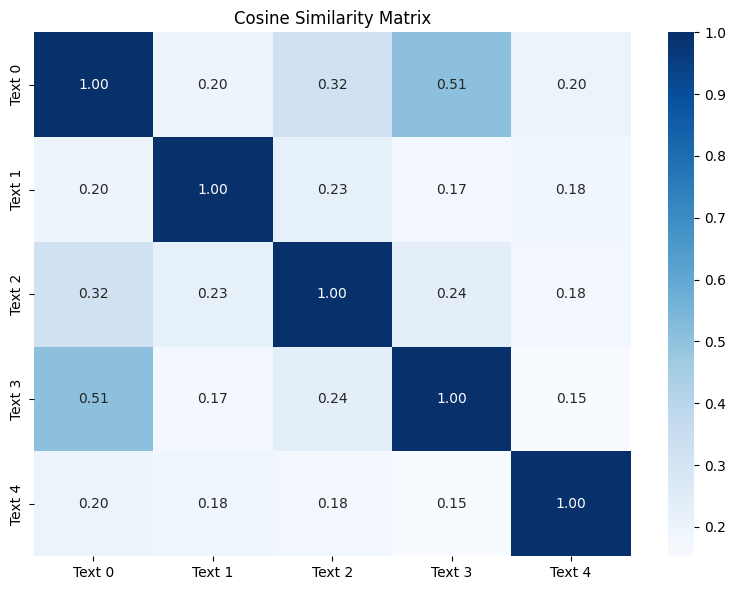

Similarity matrix saved


In [5]:
n = len(sample_texts)
similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity_matrix[i][j] = cosine_similarity(embeddings[i], embeddings[j])

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', xticklabels=[f'Text {i}' for i in range(n)], yticklabels=[f'Text {i}' for i in range(n)], cmap='Blues')
plt.title('Cosine Similarity Matrix')
plt.tight_layout()
plt.savefig('../data/embeddings/similarity_matrix.png')
plt.show()
print('Similarity matrix saved')

In [6]:
query_text = 'vehicle safety recall braking system failure'
query_emb = generate_embeddings([query_text])[0]

results = []
for i, text in enumerate(sample_texts):
    score = cosine_similarity(query_emb, embeddings[i])
    results.append((score, text))

results.sort(reverse=True)
print(f'Query: "{query_text}"\n')
print('Ranked results by cosine similarity:')
for rank, (score, text) in enumerate(results, 1):
    print(f'{rank}. [{score:.4f}] {text}')

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.75s/it]
2026-05-15 17:53:35,583 - INFO - Generated embeddings shape: (1, 384)


Query: "vehicle safety recall braking system failure"

Ranked results by cosine similarity:
1. [0.7298] Audi A4 brake failure recall safety issue
2. [0.4675] Audi Q5 steering system recall
3. [0.2948] Skoda Octavia airbag malfunction warning
4. [0.2910] Cupra Formentor electrical fault
5. [0.1732] Volkswagen Golf engine stalling defect


In [7]:
text_a = 'Audi A4 brake failure recall safety issue'
text_b = 'Audi Q5 steering system recall'
text_c = 'Cupra Formentor electrical fault'

emb_a = generate_embeddings([text_a])[0]
emb_b = generate_embeddings([text_b])[0]
emb_c = generate_embeddings([text_c])[0]

print('Comparing recall-related text vs steering recall vs electrical fault:\n')
print(f'Cosine similarity (a vs b): {cosine_similarity(emb_a, emb_b):.4f}')
print(f'Cosine similarity (a vs c): {cosine_similarity(emb_a, emb_c):.4f}')
print(f'Dot product (a vs b):       {dot_product(emb_a, emb_b):.4f}')
print(f'Dot product (a vs c):       {dot_product(emb_a, emb_c):.4f}')
print(f'Euclidean distance (a vs b):{euclidean_distance(emb_a, emb_b):.4f}')
print(f'Euclidean distance (a vs c):{euclidean_distance(emb_a, emb_c):.4f}')

Batches: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]
2026-05-15 17:53:35,944 - INFO - Generated embeddings shape: (1, 384)
Batches: 100%|██████████| 1/1 [00:00<00:00, 112.26it/s]
2026-05-15 17:53:35,957 - INFO - Generated embeddings shape: (1, 384)
Batches: 100%|██████████| 1/1 [00:00<00:00,  2.92it/s]
2026-05-15 17:53:36,302 - INFO - Generated embeddings shape: (1, 384)


Comparing recall-related text vs steering recall vs electrical fault:

Cosine similarity (a vs b): 0.5070
Cosine similarity (a vs c): 0.2046
Dot product (a vs b):       0.5070
Dot product (a vs c):       0.2046
Euclidean distance (a vs b):0.9930
Euclidean distance (a vs c):1.2613


## Setting Up ChromaDB

In [8]:
os.makedirs('../data/embeddings', exist_ok=True)

collection = get_collection(reset=False)
print(f'Collection name: data')
print(f'Documents in collection: {get_collection_count()}')

2026-05-15 17:53:37,642 - INFO - ChromaDB client connected at: /Users/elmedin.karisiksystemverification.com/Documents/private/Automotive-Industry-Tracker/data/embeddings/chroma_db
2026-05-15 17:53:37,647 - INFO - Collection 'data' ready. Count: 0
2026-05-15 17:53:37,647 - INFO - Collection 'data' ready. Count: 0


Collection name: data
Documents in collection: 0


## Adding Records to ChromaDB

In [11]:
cleaned_csv = os.path.abspath('../data/processed/cleaned/cleaned_data.csv')
df = pd.read_csv(cleaned_csv)
df = df[~df['data.make'].isin(['Unknown', 'UNKNOWN'])].copy()
print(f'Loaded {len(df)} records from cleaned dataset')
print(df.columns.tolist())

Loaded 3 records from cleaned dataset
['source', 'fetched_at', 'version', '_collection', 'data.make', 'data.model', 'data.year', 'data.recalls', 'data.file_name', 'data.document_type', 'data.source', 'data.extraction_timestamp', 'data.extraction_library', 'data.scraped_at', 'data.type', 'data.title', 'data.description', 'data.price', 'data.link', 'data.page', 'data.original_path', 'data.resized_path', 'data.thumbnail_path', 'data.webp_path', 'data.format', 'data.mode', 'data.width', 'data.height', 'data.file_size_kb', 'data.exif.file_name', 'data.exif.camera_make', 'data.exif.camera_model', 'data.exif.date_taken', 'data.exif.exposure_time', 'data.exif.aperture', 'data.exif.iso', 'data.exif.focal_length', 'data.exif.orientation', 'data.exif.gps', 'data.exif.extracted_at', 'data.processed_at', 'release_year']


In [12]:
added = add_records(df, reset=False)
print(f'Added {added} new records')
print(f'Total records in ChromaDB: {get_collection_count()}')

2026-05-15 17:55:08,344 - INFO - Collection 'data' ready. Count: 0
Batches: 100%|██████████| 1/1 [00:00<00:00,  1.15it/s]
2026-05-15 17:55:09,249 - INFO - Added 3 records to ChromaDB
2026-05-15 17:55:09,250 - INFO - Collection 'data' ready. Count: 3


Added 3 new records
Total records in ChromaDB: 3


## Querying ChromaDB by text similarity

In [13]:
results = query_collection(['brake failure safety recall'], n_results=5)
print('Query: brake failure safety recall\n')
for i, doc in enumerate(results['documents'][0]):
    meta = results['metadatas'][0][i]
    dist = results['distances'][0][i]
    print(f"{i+1}. {meta['make']} {meta['model']} ({meta['year']}) | score: {round(1-dist, 4)}")
    print(f'   {doc[:80]}')

2026-05-15 17:55:09,269 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00,  3.03it/s]

Query: brake failure safety recall

1. Audi A4 (2020) | score: 0.1228
   Audi A4
2. Audi A4 (2020) | score: 0.1228
   Audi A4
3. Skoda OCTAVIA (2020) | score: 0.0379
   Skoda OCTAVIA


In [14]:
multi_results = query_collection(
    ['engine stalling defect', 'airbag malfunction warning'],
    n_results=3
)
for q_idx, query in enumerate(['engine stalling defect', 'airbag malfunction warning']):
    print(f'\nQuery {q_idx+1}: {query}')
    for i, doc in enumerate(multi_results['documents'][q_idx]):
        meta = multi_results['metadatas'][q_idx][i]
        print(f"  {i+1}. {meta['make']} {meta['model']} ({meta['year']})")

2026-05-15 17:55:09,613 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]


Query 1: engine stalling defect
  1. Skoda OCTAVIA (2020)
  2. Audi A4 (2020)
  3. Audi A4 (2020)

Query 2: airbag malfunction warning
  1. Audi A4 (2020)
  2. Audi A4 (2020)
  3. Skoda OCTAVIA (2020)


## Metadata Filtering

In [15]:
results_eq = query_collection(
    ['safety recall defect'],
    n_results=5,
    where={'make': {'$eq': 'Audi'}}
)
print('Filter $eq - Only Audi records:')
for i, meta in enumerate(results_eq['metadatas'][0]):
    print(f"  {i+1}. {meta['make']} {meta['model']} ({meta['year']})")

2026-05-15 17:55:09,951 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00,  3.11it/s]

Filter $eq - Only Audi records:
  1. Audi A4 (2020)
  2. Audi A4 (2020)


In [16]:
results_gte = query_collection(
    ['recall defect'],
    n_results=5,
    where={'year': {'$gte': 2019}}
)
print('Filter $gte - Records from 2019 onwards:')
for i, meta in enumerate(results_gte['metadatas'][0]):
    print(f"  {i+1}. {meta['make']} {meta['model']} ({meta['year']})")

2026-05-15 17:55:10,282 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00,  1.83it/s]

Filter $gte - Records from 2019 onwards:
  1. Skoda OCTAVIA (2020)
  2. Audi A4 (2020)
  3. Audi A4 (2020)


In [17]:
results_in = query_collection(
    ['brake steering recall'],
    n_results=5,
    where={'make': {'$in': ['Audi', 'Volkswagen']}}
)
print('Filter $in - Audi or Volkswagen records:')
for i, meta in enumerate(results_in['metadatas'][0]):
    print(f"  {i+1}. {meta['make']} {meta['model']} ({meta['year']})")

2026-05-15 17:55:10,840 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 111.87it/s]

Filter $in - Audi or Volkswagen records:
  1. Audi A4 (2020)
  2. Audi A4 (2020)


In [18]:
results_and = query_collection(
    ['safety defect recall'],
    n_results=5,
    where={'$and': [{'make': {'$eq': 'Volkswagen'}}, {'year': {'$gte': 2018}}]}
)
print('Filter $and - Volkswagen records from 2018 onwards:')
for i, meta in enumerate(results_and['metadatas'][0]):
    print(f"  {i+1}. {meta['make']} {meta['model']} ({meta['year']})")

2026-05-15 17:55:10,859 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 107.17it/s]

Filter $and - Volkswagen records from 2018 onwards:


In [19]:
results_or = query_collection(
    ['recall defect'],
    n_results=5,
    where={'$or': [{'make': {'$eq': 'Skoda'}}, {'make': {'$eq': 'Cupra'}}]}
)
print('Filter $or - Skoda or Cupra records:')
for i, meta in enumerate(results_or['metadatas'][0]):
    print(f"  {i+1}. {meta['make']} {meta['model']} ({meta['year']})")

2026-05-15 17:55:10,878 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 30.97it/s]

Filter $or - Skoda or Cupra records:
  1. Skoda OCTAVIA (2020)


## Building the Search Engine Module

In [20]:
sem_results = semantic_search('brake failure recall', n_results=5)
print('Semantic search results for: brake failure recall\n')
for r in sem_results:
    print(f"{r['make']} {r['model']} ({r['year']}) | score: {r['score']}")

2026-05-15 17:55:10,928 - INFO - Semantic search: 'brake failure recall'
2026-05-15 17:55:10,930 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 87.50it/s]

Semantic search results for: brake failure recall

Audi A4 (2020) | score: 0.122
Audi A4 (2020) | score: 0.122
Skoda OCTAVIA (2020) | score: 0.035


In [21]:
kw_results = keyword_search('brake', df, n_results=5)
print('Keyword search results for: brake\n')
for r in kw_results:
    print(f"{r['make']} {r['model']} ({r['year']})")

Keyword search results for: brake



## Complete Semantic Search System

In [22]:
queries = [
    'vehicle safety issue braking system',
    'engine malfunction stalling problem',
    'airbag deployment failure'
]

for q in queries:
    compare_search(q, df, n_results=5)

2026-05-15 17:55:10,964 - INFO - Semantic search: 'vehicle safety issue braking system'
2026-05-15 17:55:10,965 - INFO - Collection 'data' ready. Count: 3



Query: 'vehicle safety issue braking system'

SEMANTIC SEARCH


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.25it/s]
2026-05-15 17:55:11,415 - INFO - Semantic search: 'engine malfunction stalling problem'
2026-05-15 17:55:11,416 - INFO - Collection 'data' ready. Count: 3


1. Audi A4 (2020) | score: 0.2113
2. Audi A4 (2020) | score: 0.2113
3. Skoda OCTAVIA (2020) | score: 0.1252

KEYWORD SEARCH
No results

Query: 'engine malfunction stalling problem'

SEMANTIC SEARCH


Batches: 100%|██████████| 1/1 [00:00<00:00, 69.39it/s]
2026-05-15 17:55:11,435 - INFO - Semantic search: 'airbag deployment failure'
2026-05-15 17:55:11,436 - INFO - Collection 'data' ready. Count: 3


1. Skoda OCTAVIA (2020) | score: 0.1644
2. Audi A4 (2020) | score: 0.1424
3. Audi A4 (2020) | score: 0.1424

KEYWORD SEARCH
No results

Query: 'airbag deployment failure'

SEMANTIC SEARCH


Batches: 100%|██████████| 1/1 [00:00<00:00, 107.31it/s]

1. Audi A4 (2020) | score: 0.2009
2. Audi A4 (2020) | score: 0.2009
3. Skoda OCTAVIA (2020) | score: 0.1358

KEYWORD SEARCH
No results


## Keyword vs Semantic Search Comparison

In [23]:
query_pairs = [
    ('brake failure', 'stopping system defect'),
    ('engine stalling', 'motor malfunction'),
    ('airbag recall', 'safety restraint issue')
]

for q1, q2 in query_pairs:
    sem1 = set([f"{r['make']} {r['model']}" for r in semantic_search(q1, n_results=5)])
    sem2 = set([f"{r['make']} {r['model']}" for r in semantic_search(q2, n_results=5)])
    kw1 = set([f"{r['make']} {r['model']}" for r in keyword_search(q1, df, n_results=5)])
    kw2 = set([f"{r['make']} {r['model']}" for r in keyword_search(q2, df, n_results=5)])

    sem_overlap = len(sem1 & sem2)
    kw_overlap = len(kw1 & kw2)

    print(f'Pair: "{q1}" vs "{q2}"')
    print(f'  Semantic overlap: {sem_overlap}/5')
    print(f'  Keyword overlap:  {kw_overlap}/5\n')

2026-05-15 17:55:11,456 - INFO - Semantic search: 'brake failure'
2026-05-15 17:55:11,457 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 118.41it/s]
2026-05-15 17:55:11,470 - INFO - Semantic search: 'stopping system defect'
2026-05-15 17:55:11,471 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 120.82it/s]
2026-05-15 17:55:11,485 - INFO - Semantic search: 'engine stalling'
2026-05-15 17:55:11,485 - INFO - Collection 'data' ready. Count: 3


Pair: "brake failure" vs "stopping system defect"
  Semantic overlap: 2/5
  Keyword overlap:  0/5



Batches: 100%|██████████| 1/1 [00:00<00:00, 117.31it/s]
2026-05-15 17:55:11,497 - INFO - Semantic search: 'motor malfunction'
2026-05-15 17:55:11,498 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 122.66it/s]
2026-05-15 17:55:11,511 - INFO - Semantic search: 'airbag recall'
2026-05-15 17:55:11,512 - INFO - Collection 'data' ready. Count: 3


Pair: "engine stalling" vs "motor malfunction"
  Semantic overlap: 2/5
  Keyword overlap:  0/5



Batches: 100%|██████████| 1/1 [00:00<00:00, 119.36it/s]
2026-05-15 17:55:11,524 - INFO - Semantic search: 'safety restraint issue'
2026-05-15 17:55:11,525 - INFO - Collection 'data' ready. Count: 3
Batches: 100%|██████████| 1/1 [00:00<00:00, 121.14it/s]

Pair: "airbag recall" vs "safety restraint issue"
  Semantic overlap: 2/5
  Keyword overlap:  0/5



## Hybrid Search

In [24]:
query = 'brake system safety recall'

print('KEYWORD SEARCH:')
kw = keyword_search(query, df, n_results=5)
for i, r in enumerate(kw, 1):
    print(f"  {i}. {r['make']} {r['model']} ({r['year']})")

print('\nSEMANTIC SEARCH:')
sem = semantic_search(query, n_results=5)
for i, r in enumerate(sem, 1):
    print(f"  {i}. {r['make']} {r['model']} ({r['year']}) | score: {r['score']}")

print('\nHYBRID SEARCH (RRF k=60):')
hyb = hybrid_search(query, df, n_results=5)
for i, r in enumerate(hyb, 1):
    print(f"  {i}. {r['make']} {r['model']} ({r['year']}) | rrf_score: {r['rrf_score']}")

2026-05-15 17:55:11,545 - INFO - Semantic search: 'brake system safety recall'
2026-05-15 17:55:11,546 - INFO - Collection 'data' ready. Count: 3


KEYWORD SEARCH:

SEMANTIC SEARCH:


Batches: 100%|██████████| 1/1 [00:00<00:00, 78.74it/s]
2026-05-15 17:55:11,563 - INFO - Hybrid search: 'brake system safety recall'
2026-05-15 17:55:11,564 - INFO - Semantic search: 'brake system safety recall'
2026-05-15 17:55:11,565 - INFO - Collection 'data' ready. Count: 3


  1. Audi A4 (2020) | score: 0.1374
  2. Audi A4 (2020) | score: 0.1374
  3. Skoda OCTAVIA (2020) | score: 0.0755

HYBRID SEARCH (RRF k=60):


Batches: 100%|██████████| 1/1 [00:00<00:00, 110.72it/s]

  1. Audi A4 (2020) | rrf_score: 0.032522
  2. Skoda OCTAVIA (2020) | rrf_score: 0.015873


## Analytical Questions

In [25]:
print('Q1: Which Audi models have the most brake-related recalls?\n')
results = semantic_search(
    'brake failure stopping system recall',
    n_results=10,
    where={'make': {'$eq': 'Audi'}}
)
for r in results:
    print(f"  {r['make']} {r['model']} ({r['year']}) | score: {r['score']}")

2026-05-15 17:55:11,584 - INFO - Semantic search: 'brake failure stopping system recall'
2026-05-15 17:55:11,586 - INFO - Collection 'data' ready. Count: 3


Q1: Which Audi models have the most brake-related recalls?



Batches: 100%|██████████| 1/1 [00:00<00:00, 111.87it/s]

  Audi A4 (2020) | score: 0.1041
  Audi A4 (2020) | score: 0.1041


In [26]:
print('Q2: Are there more engine-related recalls in recent years (2020+)?\n')
results = semantic_search(
    'engine malfunction stalling defect',
    n_results=10,
    where={'year': {'$gte': 2020}}
)
for r in results:
    print(f"  {r['make']} {r['model']} ({r['year']}) | score: {r['score']}")

2026-05-15 17:55:11,603 - INFO - Semantic search: 'engine malfunction stalling defect'
2026-05-15 17:55:11,604 - INFO - Collection 'data' ready. Count: 3


Q2: Are there more engine-related recalls in recent years (2020+)?



Batches: 100%|██████████| 1/1 [00:00<00:00, 117.91it/s]


  Skoda OCTAVIA (2020) | score: 0.1687
  Audi A4 (2020) | score: 0.1398
  Audi A4 (2020) | score: 0.1398


In [27]:
print('Q3: Which VW Group brands have airbag or safety restraint recalls?\n')
results = semantic_search(
    'airbag deployment safety restraint malfunction',
    n_results=10,
    where={'make': {'$in': ['Audi', 'Volkswagen', 'Skoda', 'Cupra']}}
)
from collections import Counter
brand_counts = Counter([r['make'] for r in results])
print('Airbag recall distribution by brand:')
for brand, count in brand_counts.most_common():
    print(f'  {brand}: {count} results')

2026-05-15 17:55:11,622 - INFO - Semantic search: 'airbag deployment safety restraint malfunction'
2026-05-15 17:55:11,623 - INFO - Collection 'data' ready. Count: 3


Q3: Which VW Group brands have airbag or safety restraint recalls?



Batches: 100%|██████████| 1/1 [00:00<00:00, 111.73it/s]


Airbag recall distribution by brand:
  Audi: 2 results
  Skoda: 1 results
